<a href="https://colab.research.google.com/github/awitz23/Diabetes_prediction/blob/main/diabetes_prediction_finale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Dependencies

In [124]:
!python --version


Python 3.11.13


In [125]:
pip install ucimlrepo

In [126]:
from imblearn.under_sampling import RandomUnderSampler

In [197]:
# Install necessary packages (run these once in your environment)
!pip install catboost xgboost lightgbm seaborn ucimlrepo

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier


# Install required packages if needed
!pip install catboost --quiet

from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.metrics import classification_report, f1_score, roc_auc_score


In [128]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# data (as pandas dataframes)
X = cdc_diabetes_health_indicators.data.features
Y = cdc_diabetes_health_indicators.data.targets

# metadata
print(cdc_diabetes_health_indicators.metadata)

# variable information
print(cdc_diabetes_health_indicators.variables)


{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

In [129]:
Y_1 = Y[Y['Diabetes_binary'] == 1].copy()


In [130]:
print(Y_1)

        Diabetes_binary
8                     1
10                    1
13                    1
17                    1
23                    1
...                 ...
253659                1
253668                1
253670                1
253676                1
253679                1

[35346 rows x 1 columns]


#Finale Pipeline

In [180]:
#50-50 Verteilung, zeigt bessere Ergebnisse als SMOTE generiertes

rus = RandomUnderSampler(random_state=42)
X_bal, y_bal = rus.fit_resample(X, Y)

In [ ]:
rus = RandomUnderSampler(random_state=42)
X_bal_new, y_bal = rus.fit_resample(X_new, Y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, stratify=y_bal, random_state=42
)


In [ ]:
cb = CatBoostClassifier(verbose=300)#iterations=100, learning_rate=0.1, max_depth=4, verbose=0)


In [ ]:
cb.fit(X_train, y_train)

In [ ]:
y_pred = cb.predict(X_train)

print("Classification Report:")
print(classification_report(y_train, y_pred, digits=3))

print("Accuracy:", accuracy_score(y_train, y_pred))
print("F1 Score:", f1_score(y_train, y_pred))
print("Precision:", precision_score(y_train, y_pred))

In [199]:

#probs = cb.predict_proba(X_test)[:, 1]  # positive class probabilities
#threshold = 0.3
#y_pred_adjusted = (probs >= threshold).astype(int)

y_pred = cb.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=3))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))
print("roc-auc:", roc_auc_score(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0      0.777     0.698     0.735      7070
           1      0.726     0.800     0.761      7069

    accuracy                          0.749     14139
   macro avg      0.752     0.749     0.748     14139
weighted avg      0.752     0.749     0.748     14139

Accuracy: 0.7489921493740718
F1 Score: 0.7612191347641795
Precision: 0.7258147292789325
recall: 0.8002546329042297
roc-auc: 0.7489957747265137


#New Pipeline nach https://www.researchgate.net/publication/377829779_Predictions_of_diabetes_through_machine_learning_models_based_on_the_health_indicators_dataset

In [156]:
# --- Step 1: Define feature types ---
binary_features = [
    'HighBP',
    'HighChol',
   # 'CholCheck',
    'Smoker',
    'Stroke',
    'HeartDiseaseorAttack',
    'PhysActivity',
   # 'Fruits',
   # 'Veggies',
    'HvyAlcoholConsump',
   # 'AnyHealthcare',
   # 'NoDocbcCost',
    'DiffWalk',
    #'Sex'
]

ordinal_features = ['GenHlth',
                    'Age',
                    'Education',
                    'Income']
ratio_features = ['BMI',
                  'MentHlth',
                  'PhysHlth']

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,1,1,1,40,1,0,0,0,0,1,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,25,1,0,0,1,0,0,...,0,1,3,0,0,0,0,7,6,1
2,1,1,1,28,0,0,0,0,1,0,...,1,1,5,30,30,1,0,9,4,8
3,1,0,1,27,0,0,0,1,1,1,...,1,0,2,0,0,0,0,11,3,6
4,1,1,1,24,0,0,0,1,1,1,...,1,0,2,3,0,0,0,11,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,1,1,1,45,0,0,0,0,1,1,...,1,0,3,0,5,0,1,5,6,7
253676,1,1,1,18,0,0,0,0,0,0,...,1,0,4,0,0,1,0,11,2,4
253677,0,0,1,28,0,0,0,1,1,0,...,1,0,1,0,0,0,0,2,5,2
253678,1,0,1,23,0,0,0,0,1,1,...,1,0,3,0,0,0,1,7,5,1


In [157]:
X_new = X.drop(columns=['CholCheck',
   'Fruits',
   'Veggies',

    'AnyHealthcare',
    'NoDocbcCost',
   'Sex'])

#Preprocessing


In [131]:
# --- Step 1: Define feature types ---
binary_features = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
    'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
    'NoDocbcCost', 'DiffWalk', 'Sex'
]

ordinal_features = ['GenHlth', 'Age', 'Education', 'Income']
ratio_features = ['BMI', 'MentHlth', 'PhysHlth']

In [160]:
# --- Step 2: Define transformers ---
scaler = StandardScaler()
ordinal_encoder = OrdinalEncoder()

# Preprocessing pipeline for models that need scaling
preprocessor = ColumnTransformer([
    ('ratio', scaler, ratio_features),
    ('ordinal', ordinal_encoder, ordinal_features)
], remainder='passthrough')  # binary features remain untouched


rus = RandomUnderSampler(random_state=42)
X_bal, y_bal = rus.fit_resample(X, Y)

In [133]:
# Get encoded feature names from the ordinal encoder
encoded_ordinal = preprocessor.named_transformers_['ordinal'].get_feature_names_out(ordinal_features)

# Combine all feature names:
columns_out = np.concatenate([
    ratio_features,             # from 'ratio' (StandardScaler)
    encoded_ordinal,            # from 'ordinal' (OrdinalEncoder)
    X_bal.drop(columns=ratio_features + ordinal_features).columns  # passthrough binary columns
])


AttributeError: 'ColumnTransformer' object has no attribute 'transformers_'

In [ ]:
import pandas as pd

X_bal_df = pd.DataFrame(X_bal_preprocessed, columns=columns_out)


In [ ]:
X_bal_df

In [ ]:
from catboost import CatBoostClassifier

catboost = CatBoostClassifier(verbose=100, random_state=42)
catboost.fit(X_bal_df, y_bal)


In [ ]:

# --- Step 3: Define models ---
models = [
   # ("XGB", XGBClassifier(use_label_encoder=False, eval_metric='logloss')),
    ("CB", CatBoostClassifier(iterations=100, learning_rate=0.1, max_depth=4, verbose=0)),
   # ("RF", RandomForestClassifier()),
    ("GBC", GradientBoostingClassifier(learning_rate=0.1, max_depth=7, n_estimators=50)),
   # ("KNN", Pipeline([('preprocess', preprocessor), ('model', KNeighborsClassifier())])),

  #  ("LogReg", Pipeline([('preprocess', preprocessor), ('model', LogisticRegression(max_iter=1000))])),

  #  ("NaiveBayes", Pipeline([('preprocess', preprocessor), ('model', GaussianNB())])),
    #("SVC", Pipeline([('preprocess', preprocessor), ('model', SVC())]))
]

In [ ]:
# --- Step 4: Evaluation setup ---
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scorer = make_scorer(f1_score)
scorer2 = make_scorer(precision_score)
scorer3 = make_scorer(recall_score)

In [ ]:
scorer

#check feature engineering

In [134]:
# Create combined ordinal feature
X_bal['Edu_Income_Sum'] = X_bal['Education'] + X_bal['Income']

# Drop original ordinal features
X_bal_fe1 = X_bal.drop(columns=['Education', 'Income'])


In [135]:
X_bal_fe2 = X_bal.drop(columns=['DiffWalk'])


In [148]:
X_bal_fe3 = X_bal

X_bal_fe3['Combined_Feature'] = (
    X_bal['DiffWalk'] +
    X_bal['GenHlth'] +
    X_bal['MentHlth'] +
    X_bal['PhysHlth']
)

# Drop the original columns
X_bal_fe3 = X_bal.drop(columns=['DiffWalk', 'GenHlth', 'MentHlth', 'PhysHlth'])


#Preprocessing check features

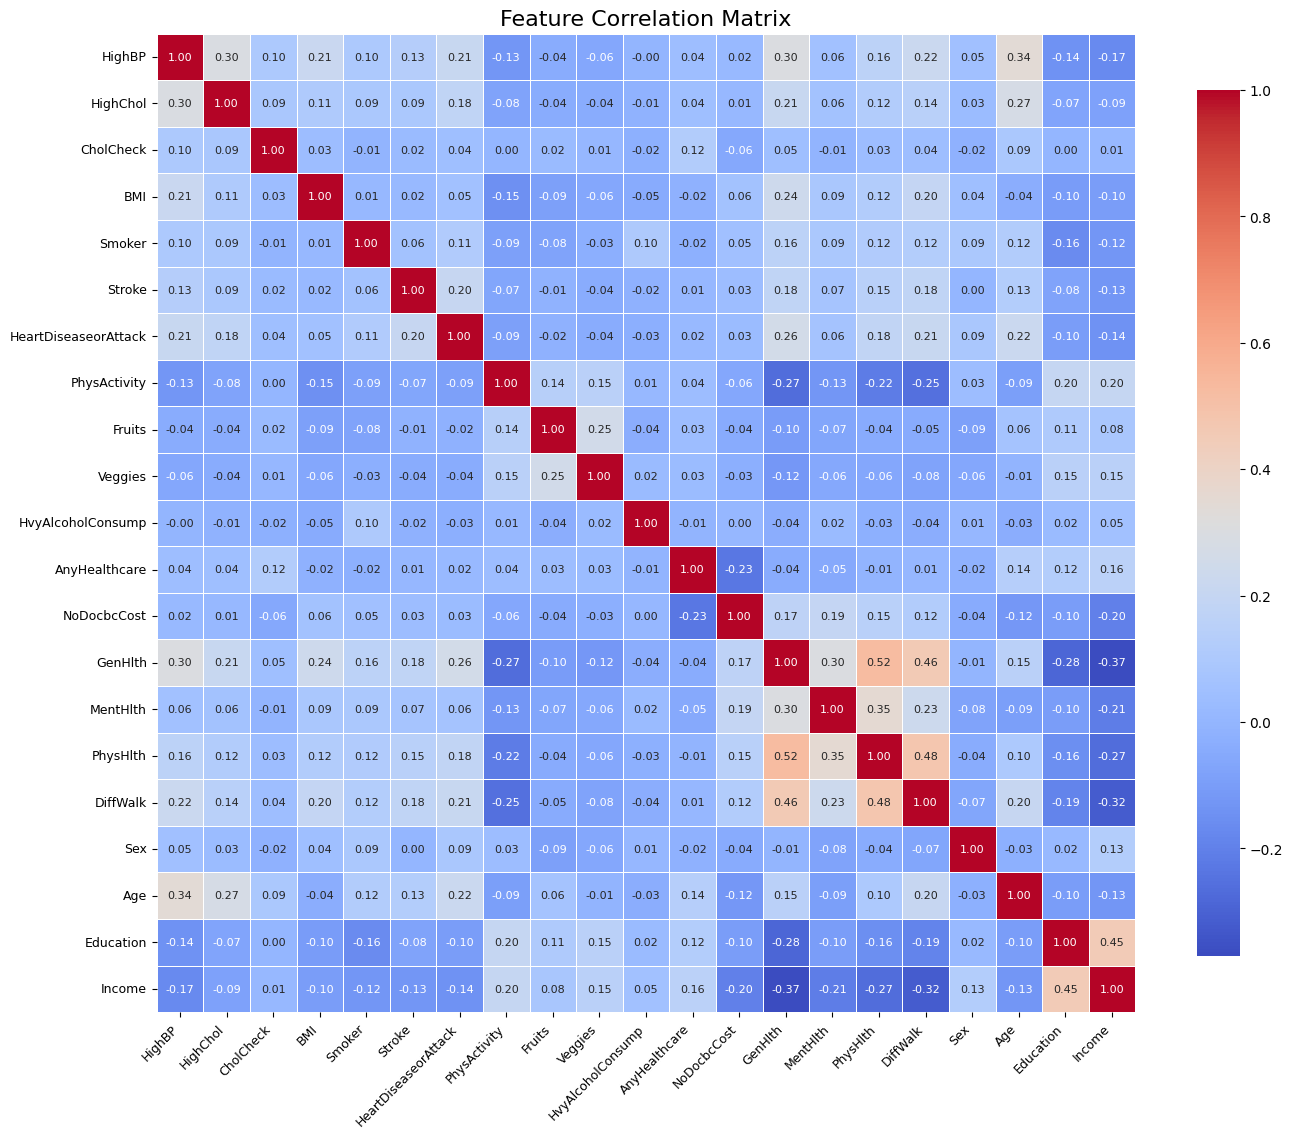

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 12))  # Adjust the figure size as needed
corr = X.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    annot_kws={"size": 8},
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()



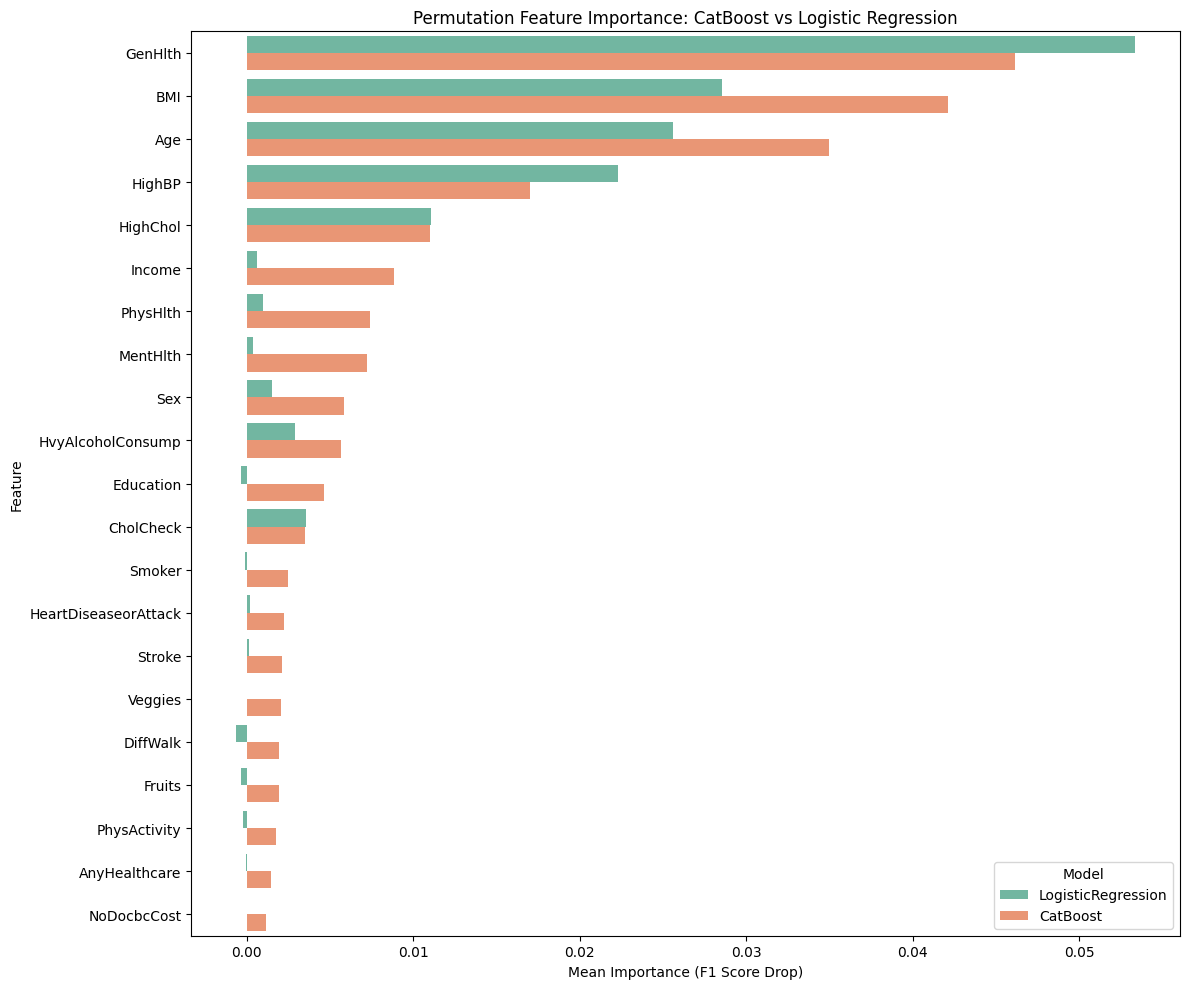

In [ ]:
# Ensure target is 1D
y_bal_1d = y_bal.values.ravel()

# ------------------ CATBOOST MODEL ------------------
catboost_model = CatBoostClassifier(verbose=0, random_state=42)
catboost_model.fit(X_bal, y_bal_1d)

catboost_result = permutation_importance(
    catboost_model, X_bal, y_bal_1d, scoring='f1', n_repeats=5, random_state=42
)

catboost_importance = pd.DataFrame({
    'feature': X_bal.columns,
    'importance_mean': catboost_result.importances_mean,
    'importance_std': catboost_result.importances_std,
    'model': 'CatBoost'
})

# ------------------ LOGISTIC REGRESSION MODEL ------------------
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_bal, y_bal_1d)

logreg_result = permutation_importance(
    logreg_model, X_bal, y_bal_1d, scoring='f1', n_repeats=5, random_state=42
)

logreg_importance = pd.DataFrame({
    'feature': X_bal.columns,
    'importance_mean': logreg_result.importances_mean,
    'importance_std': logreg_result.importances_std,
    'model': 'LogisticRegression'
})

# ------------------ COMBINE & PLOT ------------------
importance_df = pd.concat([catboost_importance, logreg_importance])
importance_df = importance_df.sort_values(by='importance_mean', ascending=False)

# Plot
plt.figure(figsize=(12, 10))
sns.barplot(
    data=importance_df,
    x='importance_mean',
    y='feature',
    hue='model',
    errorbar=('sd'),
    palette='Set2'
)
plt.title('Permutation Feature Importance: CatBoost vs Logistic Regression')
plt.xlabel('Mean Importance (F1 Score Drop)')
plt.ylabel('Feature')
plt.legend(title='Model')
plt.tight_layout()
plt.show()



In [ ]:
importance_df


,feature,importance_mean,importance_std,model
13,GenHlth,0.053358,0.001077,LogisticRegression
13,GenHlth,0.046169,0.000924,CatBoost
3,BMI,0.042102,0.000814,CatBoost
18,Age,0.034973,0.000699,CatBoost
3,BMI,0.028557,0.000943,LogisticRegression
18,Age,0.025606,0.001003,LogisticRegression
0,HighBP,0.022308,0.000756,LogisticRegression
0,HighBP,0.017001,0.000844,CatBoost
1,HighChol,0.011081,0.000786,LogisticRegression
1,HighChol,0.011015,0.000281,CatBoost


Selected features by RFE with CatBoost:
Index(['HighBP', 'HighChol', 'BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Sex',
       'Age', 'Education', 'Income'],
      dtype='object')


<ipython-input-13-f56d53ee74ee>:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_ranking_df, x='ranking', y='feature', palette='viridis')


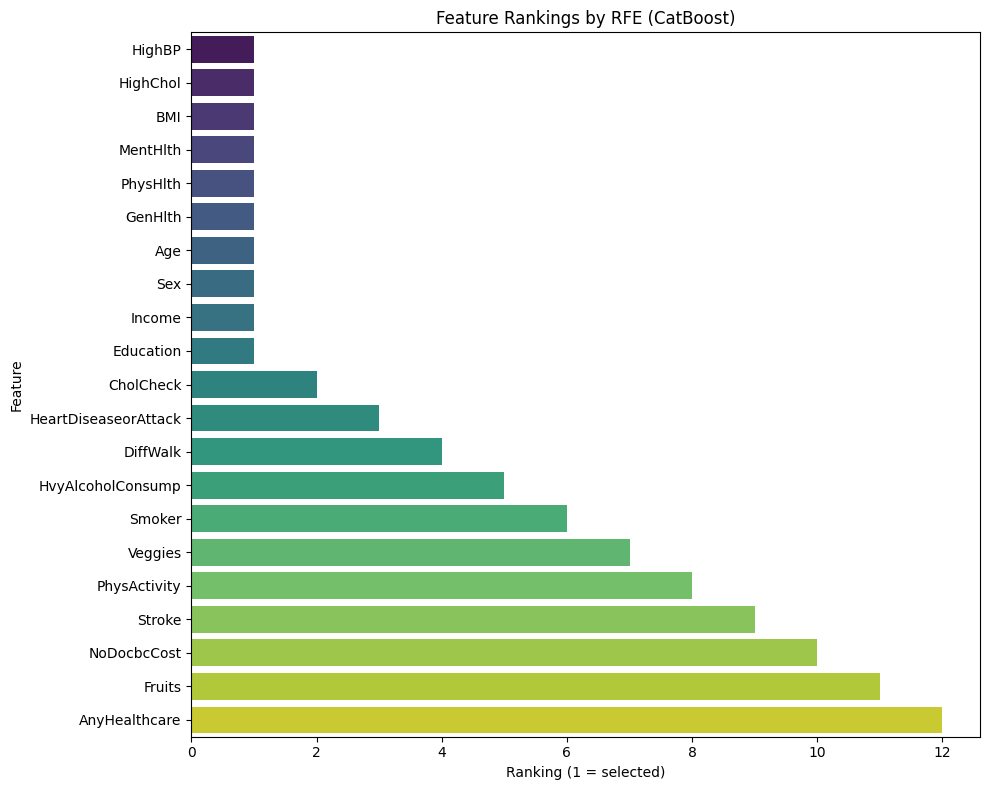

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.feature_selection import RFE
from catboost import CatBoostClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure y is 1D
y_bal_1d = y_bal.values.ravel()

# Wrapper class for CatBoost to have feature_importances_ property (read-only)
class CatBoostWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, **kwargs):
        self.model = CatBoostClassifier(**kwargs)

    def fit(self, X, y):
        self.model.fit(X, y, verbose=0)
        return self

    def predict(self, X):
        return self.model.predict(X)

    def predict_proba(self, X):
        return self.model.predict_proba(X)

    @property
    def feature_importances_(self):
        return self.model.get_feature_importance()

# Instantiate the CatBoost wrapper
catboost_wrapper = CatBoostWrapper(random_state=42)

# Create RFE with CatBoost as the estimator
rfe_catboost = RFE(estimator=catboost_wrapper, n_features_to_select=10, step=1)

# Fit RFE on data
rfe_catboost.fit(X_bal, y_bal_1d)

# Extract selected features
selected_features = X_bal.columns[rfe_catboost.support_]

print("Selected features by RFE with CatBoost:")
print(selected_features)

# Optional: visualize ranking of features
feature_ranking_df = pd.DataFrame({
    'feature': X_bal.columns,
    'ranking': rfe_catboost.ranking_
}).sort_values('ranking')

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_ranking_df, x='ranking', y='feature', palette='viridis')
plt.title('Feature Rankings by RFE (CatBoost)')
plt.xlabel('Ranking (1 = selected)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


#Preprocessing nach feature testing


In [ ]:
# --- Step 1: Define feature types ---
binary_features = [
    'HighBP',
    'HighChol',
    #'CholCheck',
    #'Smoker',
    #'Stroke',
    #'HeartDiseaseorAttack',
    #'PhysActivity',
    #'Fruits',
    #'Veggies',
    #'HvyAlcoholConsump',
    #'AnyHealthcare',
    #'NoDocbcCost',
    #'DiffWalk',
    'Sex'
]

ordinal_features = ['GenHlth',
                    'Age',
                    'Education',
                    'Income'
                    ]
ratio_features = ['BMI',
                  'MentHlth',
                  'PhysHlth'
                  ]

In [ ]:
used_features = binary_features + ordinal_features + ratio_features

# --- Step 2: Define transformers ---
scaler = StandardScaler()
ordinal_encoder = OrdinalEncoder()

# Preprocessing pipeline for models that need scaling
preprocessor = ColumnTransformer([
    ('ratio', scaler, ratio_features),
    ('ordinal', ordinal_encoder, ordinal_features)
], remainder='passthrough')  # binary features remain untouched


X_selected = X[used_features]

# --- Step 4: Resample to balance classes ---
rus = RandomUnderSampler(random_state=42)
X_bal, y_bal = rus.fit_resample(X_selected, Y)

In [ ]:

# --- Step 3: Define models ---
models = [
    ("XGB", XGBClassifier(use_label_encoder=False, eval_metric='logloss')),
    ("CB", CatBoostClassifier(learning_rate=0.11, max_depth=10, n_estimators=80, verbose=0)),
    ("RF", RandomForestClassifier()),
    ("GBC", GradientBoostingClassifier()),
    ("KNN", Pipeline([('preprocess', preprocessor), ('model', KNeighborsClassifier())])),
    #("SVC", Pipeline([('preprocess', preprocessor), ('model', SVC())]))
]

In [ ]:
# --- Step 4: Evaluation setup ---
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scorer = make_scorer(f1_score)

#next to do: drop features actually from X_bal, retrain, finetune etc.

#Model evaluation

Best CatBoost params: {'model__depth': 4, 'model__iterations': 100, 'model__learning_rate': 0.1}
Best CatBoost precision: 0.7286
Best GBC params: {'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 50}
Best GBC precision: 0.7607

In [18]:
# --- Step 5: Run cross-validation --- mit balances

results = []
names = []

for name, model in models:
    scores = cross_val_score(model, X_bal, y_bal, cv=cv, scoring=scorer, n_jobs=-1)
    results.append(scores)
    names.append(name)
    print(f"{name}: F1 = {np.mean(scores):.4f} ± {np.std(scores):.4f}")

CB: F1 = 0.7611 ± 0.0024
GBC: F1 = 0.7603 ± 0.0021


In [ ]:
# --- Step 5: Run cross-validation --- mit balances

results = []
names = []

for name, model in models:
    scores = cross_val_score(model, X_bal, y_bal, cv=cv, scoring=scorer, n_jobs=-1)
    results.append(scores)
    names.append(name)
    print(f"{name}: F1 = {np.mean(scores):.4f} ± {np.std(scores):.4f}")

XGB: F1 = 0.7531 ± 0.0015
CB: F1 = 0.7590 ± 0.0026
RF: F1 = 0.7261 ± 0.0009
GBC: F1 = 0.7582 ± 0.0017
KNN: F1 = 0.7111 ± 0.0014


#Hyperparametertuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

# --- CatBoost Tuning Pipeline ---
catboost_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', CatBoostClassifier(verbose=0))  # No class weights needed
])

catboost_params = {
    'model__depth': [4, 6, 8],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__iterations': [50, 100, 200]
}

catboost_grid = GridSearchCV(
    catboost_pipeline,
    param_grid=catboost_params,
    scoring='precision',  # Change to 'f1' or 'recall' if needed
    cv=3,
    n_jobs=-1,
    verbose=1
)

# --- Gradient Boosting Tuning Pipeline ---
gbc_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', GradientBoostingClassifier())
])

gbc_params = {
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 5, 7]
}

gbc_grid = GridSearchCV(
    gbc_pipeline,
    param_grid=gbc_params,
    scoring='precision',  # Or 'recall', 'f1'
    cv=3,
    n_jobs=-1,
    verbose=1
)

# --- Fit both models ---
catboost_grid.fit(X_bal, y_bal)
gbc_grid.fit(X_bal, y_bal)

# --- View best parameters and scores ---
print("Best CatBoost params:", catboost_grid.best_params_)
print(f"Best CatBoost precision: {catboost_grid.best_score_:.4f}")

print("Best GBC params:", gbc_grid.best_params_)
print(f"Best GBC precision: {gbc_grid.best_score_:.4f}")


Fitting 3 folds for each of 27 candidates, totalling 81 fits
Fitting 3 folds for each of 27 candidates, totalling 81 fits


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best CatBoost params: {'model__depth': 4, 'model__iterations': 100, 'model__learning_rate': 0.1}
Best CatBoost precision: 0.7286
Best GBC params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
Best GBC precision: 0.7297


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

# --- CatBoost Tuning Pipeline ---
catboost_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', CatBoostClassifier(verbose=0))  # No class weights needed
])

catboost_params = {
    'model__depth': [4, 6, 8],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__iterations': [50, 100, 200]
}

catboost_grid = GridSearchCV(
    catboost_pipeline,
    param_grid=catboost_params,
    scoring='precision',  # Change to 'f1' or 'recall' if needed
    cv=3,
    n_jobs=-1,
    verbose=1
)

# --- Gradient Boosting Tuning Pipeline ---
gbc_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', GradientBoostingClassifier())
])

gbc_params = {
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 5, 7]
}

gbc_grid = GridSearchCV(
    gbc_pipeline,
    param_grid=gbc_params,
    scoring='f1',  # Or 'recall', 'f1'
    cv=3,
    n_jobs=-1,
    verbose=1
)

# --- Fit both models ---
catboost_grid.fit(X_bal, y_bal)
gbc_grid.fit(X_bal, y_bal)

# --- View best parameters and scores ---
print("Best CatBoost params:", catboost_grid.best_params_)
print(f"Best CatBoost precision: {catboost_grid.best_score_:.4f}")

print("Best GBC params:", gbc_grid.best_params_)
print(f"Best GBC precision: {gbc_grid.best_score_:.4f}")


Fitting 3 folds for each of 27 candidates, totalling 81 fits
Fitting 3 folds for each of 27 candidates, totalling 81 fits


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best CatBoost params: {'model__depth': 4, 'model__iterations': 100, 'model__learning_rate': 0.1}
Best CatBoost precision: 0.7286
Best GBC params: {'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 50}
Best GBC precision: 0.7607


#Andere Pipeline versuchen

In [19]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import SVMSMOTE
from imblearn.pipeline import Pipeline
from imblearn.metrics import classification_report_imbalanced


In [170]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=42
)


In [171]:
lasso_selector = SelectFromModel(
    LogisticRegression(penalty='l1', solver='liblinear', random_state=42),
    threshold='0.5*median'  # or '1.25*mean' if too many features selected
)


In [172]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)


In [173]:
rf = RandomForestClassifier()#n_estimators=100, random_state=42, n_jobs=-1)
cb = CatBoostClassifier(verbose=300, learning_rate=0.1)#iterations=100, learning_rate=0.1, max_depth=4, verbose=0)
gbc = GradientBoostingClassifier()#learning_rate=0.1, max_depth=7, n_estimators=50)

In [174]:
pipeline = Pipeline(steps=[
   # ('lasso', lasso_selector),
    ('smote', smote),
    ('gbc', cb)
])


In [179]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, stratify=y_bal, random_state=42
)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

from sklearn.metrics import accuracy_score
from imblearn.pipeline import Pipeline


pipeline = Pipeline(steps=[
   # ('lasso', lasso_selector),
    #('smote', smote),
    ('gbc', cb)
])


pipeline.fit(X_train, y_train)

probs = pipeline.predict_proba(X_test)[:, 1]  # positive class probabilities
threshold = 0.3
y_pred_adjusted = (probs >= threshold).astype(int)

y_pred = pipeline.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_adjusted, digits=3))

print("F1 Score:", accuracy_score(y_test, y_pred_adjusted))


0:	learn: 0.6583038	total: 19.7ms	remaining: 19.6s
300:	learn: 0.4748197	total: 4.32s	remaining: 10s
600:	learn: 0.4559299	total: 8.63s	remaining: 5.73s
900:	learn: 0.4411789	total: 14.6s	remaining: 1.6s
999:	learn: 0.4367710	total: 16s	remaining: 0us
Classification Report:
              precision    recall  f1-score   support

           0      0.864     0.525     0.653      7070
           1      0.659     0.918     0.767      7069

    accuracy                          0.721     14139
   macro avg      0.762     0.721     0.710     14139
weighted avg      0.762     0.721     0.710     14139

F1 Score: 0.7212674163660796


In [110]:
lasso = pipeline.named_steps['lasso']
mask = lasso.get_support()  # Boolean mask: True = feature selected
selected_features = X_train.columns[mask]
print("Selected features by LASSO:")
print(selected_features.tolist())


KeyError: 'lasso'

#Experiment ab hier

In [ ]:
# mit unbalances, dafür eigene balancing logik

# Calculate scale_pos_weight for XGBoost (approx ratio of 0s to 1s)
scale_pos_weight = 86 / 14  # ≈ 6.14

models2 = [
    ("XGB", XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_pos_weight)),

    ("CB", CatBoostClassifier(
        learning_rate=0.11,
        max_depth=10,
        n_estimators=80,
        verbose=0,
        class_weights=[1, scale_pos_weight]  # [weight for 0, weight for 1]
    )),

    ("RF", RandomForestClassifier(class_weight='balanced')),

    ("GBC", GradientBoostingClassifier()),

    ("KNN", Pipeline([
        ('preprocess', preprocessor),
        ('model', KNeighborsClassifier())
    ])),

    ("LogReg", Pipeline([
        ('preprocess', preprocessor),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ])),

    ("NaiveBayes", Pipeline([
        ('preprocess', preprocessor),
        ('model', GaussianNB())
    ])),

    # Uncomment for SVC with class_weight balanced
    # ("SVC", Pipeline([
    #     ('preprocess', preprocessor),
    #     ('model', SVC(class_weight='balanced'))
    # ])),
]


In [ ]:
results = []
names = []

for name, model in models2:
    scores = cross_val_score(model, X, Y, cv=cv, scoring=scorer, n_jobs=-1)
    results.append(scores)
    names.append(name)
    print(f"{name}: F1 = {np.mean(scores):.4f} ± {np.std(scores):.4f}")

XGB: F1 = 0.4428 ± 0.0038
CB: F1 = 0.4461 ± 0.0043


KeyboardInterrupt: 

In [ ]:
# --- Step 5: Run cross-validation --- precision

results2 = []
names2 = []

for name, model in models:
    scores2 = cross_val_score(model, X, Y, cv=cv, scoring=scorer2, n_jobs=-1)
    results2.append(scores2)
    names2.append(name)
    print(f"{name}: precision = {np.mean(scores2):.4f} ± {np.std(scores2):.4f}")

XGB: precision = 0.5609 ± 0.0130
CB: precision = 0.5765 ± 0.0115


KeyboardInterrupt: 

In [ ]:
# --- Step 5: Run cross-validation --- recall

results3 = []
names3 = []

for name, model in models:
    scores3 = cross_val_score(model, X_bal, y_bal, cv=cv, scoring=scorer3, n_jobs=-1)
    results3.append(scores3)
    names3.append(name)
    print(f"{name}: recall = {np.mean(scores3):.4f} ± {np.std(scores3):.4f}")

XGB: precision = 0.7929 ± 0.0067
CB: precision = 0.7984 ± 0.0071


KeyboardInterrupt: 

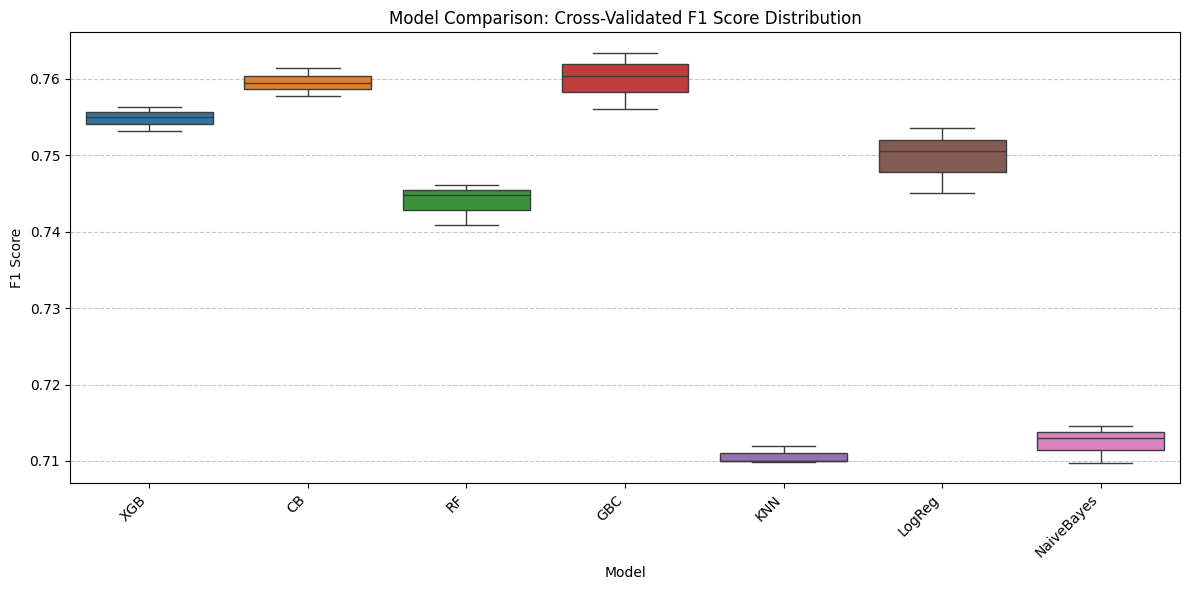

In [ ]:
#Step 6 Boxplots

# Plot boxplot of the cross-validation F1 scores
plt.figure(figsize=(12, 6))
sns.boxplot(data=results)
plt.xticks(ticks=range(len(names)), labels=names, rotation=45, ha='right')
plt.title('Model Comparison: Cross-Validated F1 Score Distribution')
plt.ylabel('F1 Score')
plt.xlabel('Model')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
#Additional models

models2 = [
    # Additional models
    ("LogisticRegression", Pipeline([('preprocessor', preprocessor), ('model', LogisticRegression(max_iter=1000))])),
    ("LDA", Pipeline([('preprocessor', preprocessor), ('model', LinearDiscriminantAnalysis())])),
    ("NaiveBayes", Pipeline([('preprocessor', preprocessor), ('model', GaussianNB())])),
    ("ExtraTrees", ExtraTreesClassifier()),
    ("LightGBM", LGBMClassifier()),
    ("MLP", Pipeline([('preprocessor', preprocessor), ('model', MLPClassifier(max_iter=500))]))
]

# Evaluation setup
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scorer = make_scorer(f1_score)

results2 = []
names2 = []

# Run cross-validation and print results
for name, model in models2:
    scores = cross_val_score(model, X_bal, y_bal, cv=cv, scoring=scorer, n_jobs=-1)
    results2.append(scores)
    names2.append(name)
    print(f"{name}: F1 = {np.mean(scores):.4f} ± {np.std(scores):.4f}")

LogisticRegression: F1 = 0.7496 ± 0.0052
LDA: F1 = 0.7521 ± 0.0062
NaiveBayes: F1 = 0.7126 ± 0.0052
ExtraTrees: F1 = 0.7313 ± 0.0070


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


LightGBM: F1 = 0.7625 ± 0.0043
MLP: F1 = 0.7552 ± 0.0111


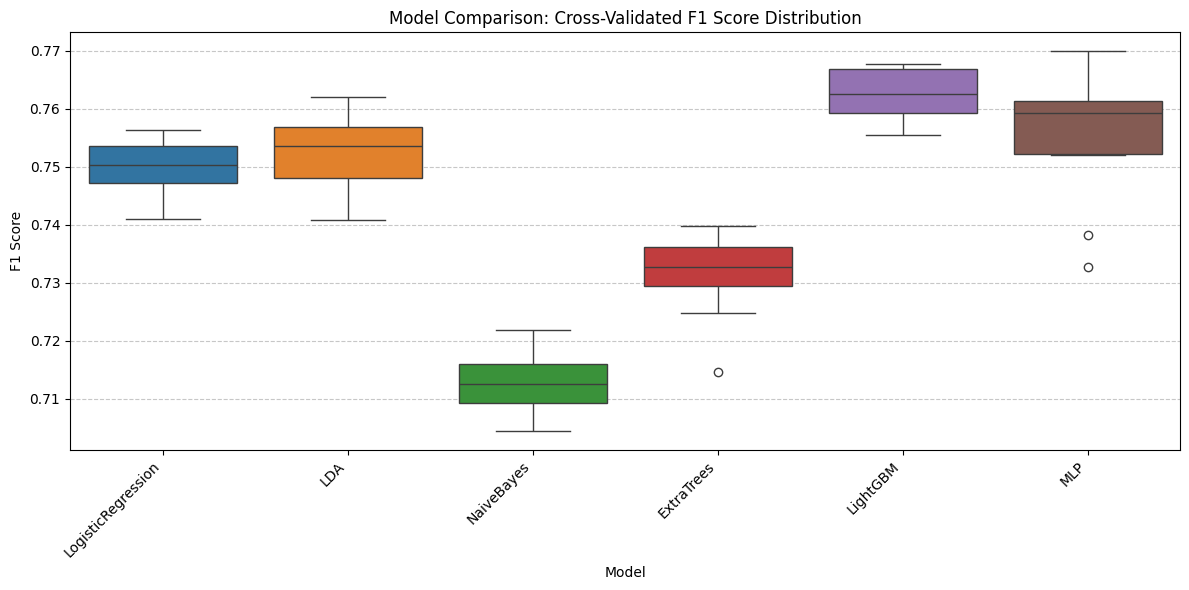

In [ ]:
#Boxplots 2

# Plot boxplot of the cross-validation F1 scores
plt.figure(figsize=(12, 6))
sns.boxplot(data=results2)
plt.xticks(ticks=range(len(names2)), labels=names2, rotation=45, ha='right')
plt.title('Model Comparison: Cross-Validated F1 Score Distribution')
plt.ylabel('F1 Score')
plt.xlabel('Model')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
#print(X_bal.columns.tolist())

'HighBP', - binary
'HighChol', - binary
'CholCheck', - binary (0 = no cholesterol check in 5 years 1 = yes cholesterol check in 5 years)
'BMI', - Integer
'Smoker', - binary (Have you smoked at least 100 cigarettes in your entire life? [Note: 5 packs = 100 cigarettes] 0 = no 1 = yes)
'Stroke', - binary
'HeartDiseaseorAttack', - binary
'PhysActivity', - binary
'Fruits', -binary
'Veggies', -binary
'HvyAlcoholConsump', -binary
'AnyHealthcare', -binary
'NoDocbcCost', -binary (Was there a time in the past 12 months when you needed to see a doctor but could not because of cost? 0 = no 1 = yes)
'GenHlth', -Integer (Would you say that in general your health is: scale 1-5 1 = excellent 2 = very good 3 = good 4 = fair 5 = poor)
'MentHlth', -Integer (ow thinking about your mental health, which includes stress, depression, and problems with emotions, for how many days during the past 30 days was your mental health not good? scale 1-30 days)
'PhysHlth', -Integer (Now thinking about your physical health, which includes physical illness and injury, for how many days during the past 30 days was your physical health not good? scale 1-30 days)
'DiffWalk', -binary
'Sex', -binary (0 = female 1 = male)
'Age', -Integer (13-level age category (_AGEG5YR see codebook) 1 = 18-24 9 = 60-64 13 = 80 or older)
'Education', -Integer (Education level (EDUCA see codebook) scale 1-6 1 = Never attended school or only kindergarten 2 = Grades 1 through 8 (Elementary) 3 = Grades 9 through 11 (Some high school) 4 = Grade 12 or GED (High school graduate) 5 = College 1 year to 3 years (Some college or technical school) 6 = College 4 years or more (College graduate))
'Income' - Integer (Income scale (INCOME2 see codebook) scale 1-8 1 = less than $10,000 5 = less than $35,000 8 = $75,000 or more)


---> binarys: as is
---> Integers:



```
# Als Code formatiert
```

#Pipeline -Vergleich

In [ ]:
# prepare configuration for cross validation test harness
seed = 7
# prepare models
models = []
models.append(("XGB", XGBClassifier()))
models.append(('CB', CatBoostClassifier(learning_rate=0.11, max_depth=12, n_estimators=80)))
#models.append(('LR', LogisticRegression()))
#models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
#models.append(('NB', GaussianNB()))
models.append(('GBC', GradientBoostingClassifier()))
models.append(('RF', RandomForestClassifier()))
models.append(('SVC', SVC()))
# evaluate each model in turn
results = []
names = []
scoring = 'f1'
for name, model in models:
 kfold = model_selection.KFold(n_splits=10,shuffle=True, random_state=seed)
 cv_results = model_selection.cross_val_score(model, X_bal, y_bal, cv=kfold, scoring=scoring)
 results.append(cv_results)
 names.append(name)
 msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
 print(msg)

# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)

averages = [np.mean(result) for result in results]


for i, avg in enumerate(averages):
    ax.text(i + 1, avg, f'Avg: {avg:.6f}', ha='center', va='bottom', fontsize=8, color='blue')

plt.savefig('all_algos_boxplot_f1.png', bbox_inches='tight')

plt.show()

NameError: name 'model_selection' is not defined